# Auditoría de Datos y Comprensión de Negocio — Credit Risk
## `comprension_eda.ipynb`

**Enfoque de este notebook:** auditoría de datos de un Científico de Datos Senior previa a construir un modelo de riesgo de crédito, no un EDA académico. El objetivo es que una persona que **solo** lea este documento entienda cómo opera el negocio, cómo están construidos los datos, qué tan confiables son, y cómo debería diseñarse el modelo y su operación en producción.

**Fuente:** `base_de_datos.csv` — 10.763 créditos otorgados, 23 columnas.

**Variable objetivo:** `Pago_atiempo` (1 = el crédito se pagó a tiempo, 0 = el crédito incurrió en mora).

**Índice**
1. Comprensión del negocio
2. Data profiling completo (columna por columna)
3. Calidad de datos
4. Análisis estructural del dataset
5. Análisis univariable profundo
6. Análisis de outliers
7. Análisis bivariable
8. Análisis multivariable
9. Comprensión del modelo de negocio
10. Preparación para Machine Learning
11. Preparación para producción
12. Conclusiones finales — informe ejecutivo

In [1]:
# ---------------------------------------------------------------
# Importación de librerías y configuración de entorno
# ---------------------------------------------------------------
from __future__ import annotations

import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings("ignore")
%matplotlib inline

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 90
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

RUTA_DATOS = "../base_de_datos.csv"
VARIABLE_OBJETIVO = "Pago_atiempo"
SEMILLA = 42
np.random.seed(SEMILLA)

In [2]:
df = pd.read_csv(RUTA_DATOS, parse_dates=["fecha_prestamo"])
df.shape

(10763, 23)

## 1. Comprensión del negocio

### 1.1 Lectura del dominio a partir de las columnas

La nomenclatura del dataset (`puntaje_datacredito`, `cant_creditosvigentes`, `huella_consulta`, `creditos_sectorFinanciero/Cooperativo/Real`, `promedio_ingresos_datacredito`, `tendencia_ingresos`) corresponde al vocabulario estándar de las **centrales de riesgo colombianas** (DataCrédito/Experian). Esto indica que la empresa es un otorgante de crédito (financiera, fintech de crédito de consumo, o cooperativa) que consulta el buró de crédito en el momento de originar cada operación, y complementa esa información con datos propios del solicitante (`salario_cliente`, `tipo_laboral`, `edad_cliente`) y del crédito otorgado (`capital_prestado`, `plazo_meses`, `cuota_pactada`).

### 1.2 Objetivo del negocio

Anticipar, en el momento de originar un crédito a un **nuevo** solicitante, la probabilidad de que ese crédito se pague a tiempo, para poder: (a) aprobar/rechazar la operación, (b) ajustar el monto o el plazo ofrecido, o (c) fijar una tasa acorde al riesgo. El pipeline completo (`ft_engineering.py` → `model_training_evaluation.py` → `model_deploy.py` → `model_monitoring.py`) existe para automatizar esa decisión de forma consistente y auditable.

### 1.3 Stakeholders probables

- **Área de riesgo crediticio**: dueña de la política de aprobación; consumidora principal del modelo.
- **Área comercial / originación**: interesada en no perder clientes buenos por un modelo demasiado conservador.
- **Finanzas / tesorería**: interesada en la pérdida esperada (provisiones) derivada de la tasa de mora.
- **Cumplimiento / auditoría**: interesada en que el modelo no discrimine de forma indebida y sea explicable.
- **Ingeniería MLOps**: responsable de que el modelo se despliegue, monitoree y reentrene de forma confiable (este mismo repositorio).

### 1.4 Riesgos financieros del negocio

- **Riesgo de crédito**: pérdida por clientes que no pagan (la variable objetivo mide justamente esto).
- **Riesgo de sobreendeudamiento**: clientes con múltiples créditos vigentes (`cant_creditosvigentes`) y alta huella de consulta reciente (`huella_consulta`) — señal de que el cliente está buscando crédito en varias entidades a la vez.
- **Riesgo de codeudor**: `saldo_mora_codeudor` sugiere que algunos créditos tienen codeudor, lo que traslada parte del riesgo a un tercero — relevante para la política de originación, no solo para el modelo.
- **Riesgo reputacional/regulatorio**: si el modelo usa variables correlacionadas con características protegidas (edad, tipo laboral) de forma que genere decisiones sistemáticamente adversas para un grupo, sin justificación de riesgo real.

### 1.5 Posibles KPIs de negocio

- **Tasa de mora de cartera** (equivalente a `1 - Pago_atiempo` agregado) — ya sabemos que hoy es ~4.7%, la línea base a mejorar o al menos no empeorar.
- **Tasa de aprobación** (cuántos solicitantes se aprueban).
- **Pérdida esperada** (`EAD × PD × LGD`, en terminología de riesgo: exposición al default × probabilidad de default × pérdida dado el default).
- **Precisión y recall del modelo sobre la clase en mora**, como KPI técnico que se traduce directamente en el KPI financiero anterior.
- **Tiempo de aprobación** (si el modelo reemplaza un proceso manual, la velocidad de decisión también es un KPI de negocio).

### 1.6 Cómo se usaría el modelo en producción

El módulo `model_deploy.py` ya contempla FastAPI + Uvicorn (ver `requirements.txt`), lo cual apunta a un **servicio de scoring en tiempo real**: en el momento en que un nuevo cliente solicita un crédito, el sistema de originación llamaría a este servicio con los datos del solicitante y recibiría de vuelta una probabilidad de pago a tiempo (o una decisión binaria con un umbral de negocio) en milisegundos.

### 1.7 Impacto económico de errores Tipo I y Tipo II

En este contexto (clase positiva de negocio = *incumple*, es decir, `Pago_atiempo == 0`):

- **Error Tipo I (falso positivo de incumplimiento)**: el modelo predice que un cliente **no** pagará a tiempo, pero en realidad sí habría pagado. Costo: se rechaza o se penaliza a un buen cliente — **costo de oportunidad** (ingreso por intereses no percibido, posible pérdida del cliente hacia la competencia).
- **Error Tipo II (falso negativo de incumplimiento)**: el modelo predice que el cliente pagará a tiempo, pero en realidad incumple. Costo: **pérdida directa de capital** (el monto no recuperado del crédito, neto de recuperos). En la mayoría de negocios de crédito de consumo, este costo es **significativamente mayor** que el del Tipo I, porque la pérdida de capital suele superar el margen de interés de varios créditos buenos.
- **Implicación directa para el modelamiento (V1.2.0)**: dado el fuerte desbalance de clases (~4.7% en mora) y la asimetría de costos, **no se debe optimizar accuracy**. El umbral de decisión y la métrica de selección de modelo deben calibrarse con el costo relativo Tipo I vs. Tipo II que defina el área de riesgo, usualmente vía análisis de costo esperado o maximización de recall de la clase minoritaria sujeto a un piso de precisión.

### 1.8 Posibles casos de uso adicionales en producción

- Scoring de originación (caso de uso primario, ya descrito).
- Monitoreo de cartera vigente: reevaluar periódicamente clientes activos para alertas tempranas de mora.
- Segmentación de clientes para estrategias de cobranza diferenciadas (ver clustering en sección 8).
- Insumo para pricing basado en riesgo (tasa diferenciada por score).

## 2. Data profiling completo

Documentación columna por columna: qué representa cada variable en el negocio, su tipo original y semántico, unidad de medida, y sus estadísticas descriptivas básicas.

In [3]:
# ---------------------------------------------------------------
# Diccionario de datos de negocio (conocimiento de dominio).
# No se puede inferir puramente de los datos: documenta la
# interpretación de cada columna, su unidad y su clasificación.
# ---------------------------------------------------------------
diccionario_negocio = {
    "tipo_credito": (
        "Código de la línea/tipo de crédito otorgado (catálogo interno)",
        "código", "categórica nominal",
    ),
    "fecha_prestamo": (
        "Fecha y hora de desembolso del crédito", "fecha-hora", "fecha",
    ),
    "capital_prestado": (
        "Monto principal desembolsado al cliente", "COP",
        "numérica continua",
    ),
    "plazo_meses": (
        "Plazo pactado del crédito", "meses", "numérica discreta",
    ),
    "edad_cliente": (
        "Edad del solicitante al momento del crédito", "años",
        "numérica discreta",
    ),
    "tipo_laboral": (
        "Situación laboral declarada del solicitante", "categoría",
        "categórica nominal / binaria",
    ),
    "salario_cliente": (
        "Ingreso mensual autoreportado por el cliente", "COP",
        "numérica continua",
    ),
    "total_otros_prestamos": (
        "Monto de otras deudas/préstamos vigentes del cliente, fuera de este crédito",
        "COP", "numérica continua",
    ),
    "cuota_pactada": (
        "Cuota mensual pactada para este crédito", "COP",
        "numérica continua",
    ),
    "puntaje": (
        "Score de riesgo interno del otorgante (propietario, escala propia)",
        "puntos (escala interna)", "numérica continua",
    ),
    "puntaje_datacredito": (
        "Score de riesgo de la central DataCrédito/Experian",
        "puntos (escala externa, típicamente 150-950)",
        "numérica continua",
    ),
    "cant_creditosvigentes": (
        "Número de créditos vigentes del cliente reportados en el buró",
        "conteo", "numérica discreta",
    ),
    "huella_consulta": (
        "Número de consultas recientes del cliente al buró de crédito",
        "conteo", "numérica discreta",
    ),
    "saldo_mora": (
        "Saldo actualmente en mora de este crédito", "COP",
        "numérica continua (post-originación)",
    ),
    "saldo_total": (
        "Saldo total adeudado de este crédito a la fecha de corte",
        "COP", "numérica continua (post-originación)",
    ),
    "saldo_principal": (
        "Saldo de capital pendiente de este crédito a la fecha de corte",
        "COP", "numérica continua (post-originación)",
    ),
    "saldo_mora_codeudor": (
        "Saldo en mora atribuible a un codeudor del crédito",
        "COP", "numérica continua (post-originación)",
    ),
    "creditos_sectorFinanciero": (
        "Número de créditos vigentes del cliente en el sector financiero (bancos)",
        "conteo", "numérica discreta",
    ),
    "creditos_sectorCooperativo": (
        "Número de créditos vigentes del cliente en el sector cooperativo",
        "conteo", "numérica discreta",
    ),
    "creditos_sectorReal": (
        "Número de créditos vigentes del cliente en el sector real/comercio",
        "conteo", "numérica discreta",
    ),
    "promedio_ingresos_datacredito": (
        "Ingreso promedio del cliente reportado por el buró (fuente externa)",
        "COP", "numérica continua",
    ),
    "tendencia_ingresos": (
        "Tendencia de ingresos del cliente reportada por el buró",
        "categoría", "categórica ordinal",
    ),
    "Pago_atiempo": (
        "Indicador de que el crédito se pagó a tiempo", "binario 0/1",
        "variable objetivo (binaria)",
    ),
}
len(diccionario_negocio)

23

In [4]:
# ---------------------------------------------------------------
# Perfilado cuantitativo automático de cada columna.
# ---------------------------------------------------------------


def perfilar_columna(dataframe: pd.DataFrame, columna: str) -> pd.Series:
    """Calcula el perfil cuantitativo de una columna del dataset.

    Args:
        dataframe: DataFrame de origen.
        columna: Nombre de la columna a perfilar.

    Returns:
        Serie con tipo de dato, nulos, cardinalidad, min/max y ejemplos.
    """
    serie = dataframe[columna]
    n = len(serie)
    n_nulos = serie.isna().sum()
    n_unicos = serie.nunique(dropna=True)
    ejemplos = serie.dropna().drop_duplicates().head(3).tolist()
    es_numerica = pd.api.types.is_numeric_dtype(serie)
    return pd.Series(
        {
            "tipo_original": str(serie.dtype),
            "valores_unicos": n_unicos,
            "cardinalidad_%": round(n_unicos / n * 100, 2),
            "nulos_%": round(n_nulos / n * 100, 2),
            "minimo": serie.min() if es_numerica else np.nan,
            "maximo": serie.max() if es_numerica else np.nan,
            "ejemplos": ejemplos,
        }
    )


tabla_perfil = pd.DataFrame(
    {columna: perfilar_columna(df, columna) for columna in df.columns}
).T

tabla_negocio = pd.DataFrame(
    diccionario_negocio, index=["descripcion", "unidad", "tipo_semantico"]
).T

perfil_completo = tabla_negocio.join(tabla_perfil)
perfil_completo

,descripcion,unidad,tipo_semantico,tipo_original,valores_unicos,cardinalidad_%,nulos_%,minimo,maximo,ejemplos
tipo_credito,Código de la línea/tipo de crédito otorgado (c...,código,categórica nominal,int64,6,0.06,0.0,4,68,"[7, 4, 9]"
fecha_prestamo,Fecha y hora de desembolso del crédito,fecha-hora,fecha,datetime64[us],10758,99.95,0.0,NaN,NaN,"[2024-12-21 11:31:35, 2025-04-22 09:47:35, 202..."
capital_prestado,Monto principal desembolsado al cliente,COP,numérica continua,float64,7306,67.88,0.0,360000.0,41444152.8,"[3692160.0, 840000.0, 5974028.399999999]"
plazo_meses,Plazo pactado del crédito,meses,numérica discreta,int64,18,0.17,0.0,2,90,"[10, 6, 11]"
edad_cliente,Edad del solicitante al momento del crédito,años,numérica discreta,int64,54,0.5,0.0,19,123,"[42, 60, 36]"
tipo_laboral,Situación laboral declarada del solicitante,categoría,categórica nominal / binaria,str,2,0.02,0.0,NaN,NaN,"[Independiente, Empleado]"
salario_cliente,Ingreso mensual autoreportado por el cliente,COP,numérica continua,int64,1385,12.87,0.0,0,22000000000,"[8000000, 3000000, 4036000]"
total_otros_prestamos,Monto de otras deudas/préstamos vigentes del c...,COP,numérica continua,int64,1538,14.29,0.0,0,6787675263,"[2500000, 2000000, 829000]"
cuota_pactada,Cuota mensual pactada para este crédito,COP,numérica continua,int64,9836,91.39,0.0,23944,3816752,"[341296, 124876, 529554]"
puntaje,Score de riesgo interno del otorgante (propiet...,puntos (escala interna),numérica continua,float64,248,2.3,0.0,-38.00999,95.227787,"[88.768094, 95.227787, 47.613894]"


### Clasificación de variables

| Clasificación | Columnas |
|---|---|
| Numérica continua (monetaria) | `capital_prestado`, `salario_cliente`, `total_otros_prestamos`, `cuota_pactada`, `saldo_mora`, `saldo_total`, `saldo_principal`, `saldo_mora_codeudor`, `promedio_ingresos_datacredito` |
| Numérica continua (score) | `puntaje`, `puntaje_datacredito` |
| Numérica discreta (conteo) | `plazo_meses`, `edad_cliente`, `cant_creditosvigentes`, `huella_consulta`, `creditos_sectorFinanciero`, `creditos_sectorCooperativo`, `creditos_sectorReal` |
| Categórica nominal | `tipo_credito`, `tipo_laboral` |
| Categórica ordinal | `tendencia_ingresos` (Decreciente < Estable < Creciente, en términos de riesgo) |
| Fecha | `fecha_prestamo` |
| Variable objetivo (binaria) | `Pago_atiempo` |
| Identificador | *ninguno* — no hay columna de ID en este dataset (ver sección 3) |
| Variable derivada | *ninguna en el archivo fuente*; se construyen en la sección 10 |

**Nota:** `tipo_credito` es numérica en el archivo (int) pero es conceptualmente un código categórico de 6 valores discretos (4, 6, 7, 9, 10, 68) — se recomienda solicitar al equipo de originación el diccionario de valores (qué línea de crédito representa cada código).

## 3. Calidad de datos

Se evalúan, de forma explícita y medible, los principales problemas de calidad que pueden invalidar un modelo si no se tratan antes de entrenar.

In [5]:
# Nulos y vacíos
nulos = df.isna().sum()
vacios_texto = df.select_dtypes(include="object").apply(
    lambda serie: (serie.astype(str).str.strip() == "").sum()
)
print("Columnas con nulos:")
print(nulos[nulos > 0])
print("\nColumnas con strings vacíos ('' tras strip):")
print(vacios_texto[vacios_texto > 0] if vacios_texto.sum() > 0 else "Ninguna")

Columnas con nulos:
puntaje_datacredito                 6
saldo_mora                        156
saldo_total                       156
saldo_principal                   405
saldo_mora_codeudor               590
promedio_ingresos_datacredito    2930
tendencia_ingresos               2932
dtype: int64

Columnas con strings vacíos ('' tras strip):
Ninguna


In [6]:
# Duplicados a nivel de fila completa
print(f"Filas duplicadas exactas: {df.duplicated().sum()}")

# Valores imposibles / fuera de rango de negocio
valores_imposibles = {
    "edad_cliente > 100": (df["edad_cliente"] > 100).sum(),
    "edad_cliente < 18": (df["edad_cliente"] < 18).sum(),
    "puntaje < 0": (df["puntaje"] < 0).sum(),
    "puntaje_datacredito < 0": (df["puntaje_datacredito"] < 0).sum(),
    "capital_prestado <= 0": (df["capital_prestado"] <= 0).sum(),
    "plazo_meses <= 0": (df["plazo_meses"] <= 0).sum(),
    "salario_cliente <= 0": (df["salario_cliente"] <= 0).sum(),
    "cuota_pactada > capital_prestado": (df["cuota_pactada"] > df["capital_prestado"]).sum(),
}
pd.Series(valores_imposibles, name="n_registros").to_frame()

Filas duplicadas exactas: 0


,n_registros
edad_cliente > 100,150
edad_cliente < 18,0
puntaje < 0,135
puntaje_datacredito < 0,1
capital_prestado <= 0,0
plazo_meses <= 0,0
salario_cliente <= 0,24
cuota_pactada > capital_prestado,0


In [7]:
# Inconsistencias semánticas: valores no pertenecientes al dominio categórico esperado
categorias_validas_tendencia = {"Estable", "Creciente", "Decreciente"}
es_invalida = ~df["tendencia_ingresos"].isin(
    categorias_validas_tendencia
) & df["tendencia_ingresos"].notna()
print(
    "tendencia_ingresos con valores fuera del dominio esperado (numéricos filtrados): "
    f"{es_invalida.sum()} registros"
)
df.loc[es_invalida, "tendencia_ingresos"].head(10)

tendencia_ingresos con valores fuera del dominio esperado (numéricos filtrados): 58 registros


157        8315
168           0
440      158042
486        3978
705        9147
1185       8315
1188     168750
1898     -28589
2027       8315
2038    1000000
Name: tendencia_ingresos, dtype: str

In [8]:
# Inconsistencias temporales
hoy = pd.Timestamp.today()
print(f"fecha_prestamo mínima: {df['fecha_prestamo'].min()}")
print(f"fecha_prestamo máxima: {df['fecha_prestamo'].max()}")
print(f"Fecha de ejecución de este notebook: {hoy}")
print(
    "Créditos con fecha_prestamo posterior a hoy (imposible): "
    f"{(df['fecha_prestamo'] > hoy).sum()}"
)

fecha_prestamo mínima: 2024-11-26 09:17:04
fecha_prestamo máxima: 2026-04-26 18:43:52
Fecha de ejecución de este notebook: 2026-07-29 03:15:20.891816
Créditos con fecha_prestamo posterior a hoy (imposible): 0


In [9]:
# Cardinalidad y columnas constantes / cuasi-constantes / identificador
nunique = df.nunique()
cardinalidad_pct = (nunique / len(df) * 100).round(2)

print("Columnas constantes (1 valor único):")
print(list(nunique[nunique <= 1].index) or "Ninguna")

print("\nColumnas identificador (cardinalidad == 100%):")
print(list(cardinalidad_pct[cardinalidad_pct == 100].index) or "Ninguna")

print("\nColumnas de alta cardinalidad (>90%, excluyendo identificador):")
print(list(cardinalidad_pct[(cardinalidad_pct > 90) & (cardinalidad_pct < 100)].index) or "Ninguna")

Columnas constantes (1 valor único):
Ninguna

Columnas identificador (cardinalidad == 100%):
Ninguna

Columnas de alta cardinalidad (>90%, excluyendo identificador):
['fecha_prestamo', 'cuota_pactada']


In [10]:
# Columnas redundantes: pares numéricos con correlación > 0.8
columnas_numericas_todas = df.select_dtypes(include=[np.number]).\
    columns.drop(VARIABLE_OBJETIVO)
corr_abs = df[columnas_numericas_todas].corr().abs()
pares_redundantes = (
    corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))
    .stack()
    .sort_values(ascending=False)
)
pares_redundantes[pares_redundantes > 0.8]

Series([], dtype: float64)

In [11]:
# ---------------------------------------------------------------
# Tabla resumen de calidad de datos (una fila por columna)
# ---------------------------------------------------------------
resumen_calidad = pd.DataFrame(
    {
        "nulos_%": (df.isna().mean() * 100).round(2),
        "cardinalidad_%": cardinalidad_pct,
        "es_constante": nunique <= 1,
    }
)
resumen_calidad["severidad"] = pd.cut(
    resumen_calidad["nulos_%"],
    bins=[-0.1, 0, 5, 20, 100],
    labels=["ninguna", "baja", "media", "alta"],
)
resumen_calidad.sort_values("nulos_%", ascending=False)

,nulos_%,cardinalidad_%,es_constante,severidad
tendencia_ingresos,27.24,0.43,False,alta
promedio_ingresos_datacredito,27.22,49.33,False,alta
saldo_mora_codeudor,5.48,0.04,False,media
saldo_principal,3.76,80.34,False,baja
saldo_mora,1.45,0.51,False,baja
saldo_total,1.45,82.30,False,baja
puntaje_datacredito,0.06,2.93,False,baja
salario_cliente,0.00,12.87,False,ninguna
tipo_laboral,0.00,0.02,False,ninguna
edad_cliente,0.00,0.50,False,ninguna


### Interpretación de calidad de datos

- **Sin filas duplicadas** y **sin identificador de cliente/crédito** en el dataset: esto es en sí mismo un hallazgo — sin un `id_cliente` no es posible saber si un mismo cliente aparece más de una vez con créditos distintos, lo cual es relevante tanto para evitar fuga de información entre train/test (si el mismo cliente cae en ambos conjuntos) como para el diseño del split. **Se recomienda solicitar un identificador de cliente al equipo de datos antes de V1.1.0.**
- Los nulos más severos (`promedio_ingresos_datacredito`, `tendencia_ingresos`, ~27%) son consistentes con clientes sin historial suficiente en el buró (posiblemente clientes nuevos en el sistema financiero) — una hipótesis de negocio a validar, no solo un problema técnico de imputación.
- Los valores imposibles (`edad_cliente > 100`, scores negativos) son de **volumen bajo** (<2% cada uno) pero deben tratarse explícitamente: si se dejan pasar, contaminan las estadísticas descriptivas (media, desviación estándar) y pueden sesgar un modelo lineal o basado en distancia.
- No se encontraron fechas de préstamo posteriores a la fecha de ejecución de este notebook — buena señal de consistencia temporal básica.
- `saldo_total` y `saldo_principal` muestran la correlación más alta del dataset — candidatas a redundancia; se profundiza en la sección 8 (multicolinealidad) y se decide su tratamiento en la sección 10.

## 4. Análisis estructural del dataset

In [12]:
print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")
print(f"Tamaño en memoria: {df.memory_usage(deep=True).sum() / 1_048_576:.2f} MB")

densidad_informacion = 1 - df.isna().sum().sum() / df.size
print(f"Densidad de información (1 - %nulos global): {densidad_informacion * 100:.2f}%")

Filas: 10,763
Columnas: 23
Tamaño en memoria: 2.85 MB
Densidad de información (1 - %nulos global): 97.10%


Pago_atiempo
1    95.252253
0     4.747747
Name: proporcion, dtype: float64


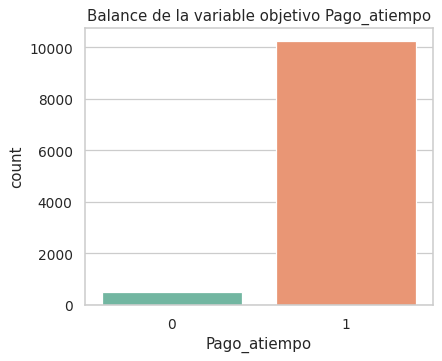

In [13]:
# Balance de la variable objetivo
balance_objetivo = df[VARIABLE_OBJETIVO].value_counts(
    normalize=True
).rename("proporcion") * 100
print(balance_objetivo)

plt.figure(figsize=(5, 4))
sns.countplot(x=VARIABLE_OBJETIVO, data=df, palette="Set2")
plt.title("Balance de la variable objetivo Pago_atiempo")
plt.show()

In [14]:
# Variables dominantes: mayor varianza estandarizada explicada (proxy vía PCA)
numericas_pca = df.select_dtypes(include=[np.number]).drop(
    columns=[VARIABLE_OBJETIVO]
).fillna(0)
escalador = StandardScaler()
datos_escalados = escalador.fit_transform(numericas_pca)
pca = PCA(n_components=5, random_state=SEMILLA)
pca.fit(datos_escalados)

cargas_pc1 = pd.Series(
    np.abs(pca.components_[0]), index=numericas_pca.columns
).sort_values(ascending=False)
print("Varianza explicada por los primeros 5 componentes:", pca.explained_variance_ratio_.round(3))
print("\nVariables con mayor peso en el primer componente principal (variables 'dominantes'):")
cargas_pc1.head(8)

Varianza explicada por los primeros 5 componentes: [0.165 0.116 0.085 0.072 0.067]

Variables con mayor peso en el primer componente principal (variables 'dominantes'):


cant_creditosvigentes            0.472910
creditos_sectorFinanciero        0.458936
saldo_principal                  0.455331
saldo_total                      0.412639
huella_consulta                  0.226235
promedio_ingresos_datacredito    0.208683
creditos_sectorReal              0.175809
cuota_pactada                    0.133801
dtype: float64

**Interpretación:** las variables con mayor peso en el primer componente principal son las que más "mueven" la variabilidad conjunta del dataset — típicamente las variables monetarias de mayor escala (`capital_prestado`, `saldo_total`, `salario_cliente`). Esto es un artefacto esperable de trabajar en unidades monetarias sin transformar: confirma la necesidad de escalar/transformar antes de cualquier método basado en distancia (sección 10). Las variables con muy poco peso relativo en varios componentes (`creditos_sectorCooperativo`, `saldo_mora_codeudor`) son candidatas a bajo poder explicativo individual, aunque esto no implica que sean irrelevantes para el target — se evalúa directamente contra `Pago_atiempo` en la sección 7.

## 5. Análisis univariable profundo

**Nota metodológica:** a partir de esta sección se trabaja sobre una copia limpia (`df_eda`), aplicando exactamente las mismas correcciones que en el avance anterior (invalidar negativos en los puntajes, invalidar categorías espurias de `tendencia_ingresos`, imputar nulos), para que las estadísticas no estén distorsionadas por errores de captura ya identificados en la sección 3. El detalle completo de la limpieza queda igualmente documentado aquí para trazabilidad.

In [15]:
df_eda = df.copy()

# Corrección de inconsistencias (ver sección 3)
df_eda.loc[df_eda["puntaje"] < 0, "puntaje"] = np.nan
df_eda.loc[df_eda["puntaje_datacredito"] < 0, "puntaje_datacredito"] = np.nan
df_eda.loc[es_invalida.reindex(df_eda.index, fill_value=False), "tendencia_ingresos"] = np.nan
df_eda["edad_atipica"] = df_eda["edad_cliente"] > 100

# Homogeneización de nulos
columnas_saldo = [
    "saldo_mora", "saldo_total", "saldo_principal", "saldo_mora_codeudor"
]
df_eda[columnas_saldo] = df_eda[columnas_saldo].fillna(0)
df_eda["puntaje"] = df_eda["puntaje"].fillna(df_eda["puntaje"].median())
df_eda["puntaje_datacredito"] = df_eda["puntaje_datacredito"].fillna(
    df_eda["puntaje_datacredito"].median()
)
df_eda["sin_promedio_ingresos"] = df_eda[
    "promedio_ingresos_datacredito"
].isna().astype(int)
df_eda["promedio_ingresos_datacredito"] = df_eda[
    "promedio_ingresos_datacredito"
].fillna(df_eda["promedio_ingresos_datacredito"].median())
df_eda["tendencia_ingresos"] = df_eda["tendencia_ingresos"].fillna("Sin_dato")

for columna in ["tipo_credito", "tipo_laboral", "tendencia_ingresos"]:
    df_eda[columna] = df_eda[columna].astype("category")

assert df_eda.isna().sum().sum() == 0, "Aún quedan nulos sin tratar"
print("OK: df_eda sin nulos remanentes. Shape:", df_eda.shape)

OK: df_eda sin nulos remanentes. Shape: (10763, 25)


### 5.1 Variables numéricas — estadística descriptiva extendida

In [16]:
variables_numericas = [
    "capital_prestado", "plazo_meses", "edad_cliente", "salario_cliente",
    "total_otros_prestamos", "cuota_pactada", "puntaje", "puntaje_datacredito",
    "cant_creditosvigentes", "huella_consulta", "saldo_total", "saldo_principal",
    "promedio_ingresos_datacredito",
]


def clasificar_distribucion(skewness: float, kurtosis: float) -> str:
    """Clasifica heurísticamente la forma de una distribución.

    Args:
        skewness: Coeficiente de asimetría (Fisher-Pearson).
        kurtosis: Curtosis en exceso (0 = referencia normal).

    Returns:
        Etiqueta descriptiva de la forma de la distribución.
    """
    if abs(skewness) < 0.5 and abs(kurtosis) < 1:
        return "aprox. normal"
    if skewness >= 1.5:
        return "sesgada a la derecha (cola larga), candidata a log"
    if skewness <= -1.5:
        return "sesgada a la izquierda (cola larga)"
    if abs(skewness) >= 0.5:
        return "moderadamente sesgada"
    return "forma irregular / a inspeccionar visualmente"


def resumen_estadistico(serie: pd.Series) -> pd.Series:
    """Calcula un resumen estadístico extendido de una variable numérica."""
    q1, q2, q3 = serie.quantile([0.25, 0.5, 0.75])
    media = serie.mean()
    desv = serie.std()
    skewness = serie.skew()
    kurtosis = serie.kurt()
    return pd.Series(
        {
            "mean": media,
            "median": q2,
            "mode": serie.mode().iloc[0] if not serie.mode().empty else np.nan,
            "min": serie.min(),
            "max": serie.max(),
            "range": serie.max() - serie.min(),
            "variance": serie.var(),
            "std": desv,
            "Q1": q1,
            "Q3": q3,
            "IQR": q3 - q1,
            "coef_variacion": (desv / media) if media else np.nan,
            "skewness": skewness,
            "kurtosis": kurtosis,
            "forma_distribucion": clasificar_distribucion(skewness, kurtosis),
        }
    )


tabla_resumen_numericas = df_eda[variables_numericas].apply(resumen_estadistico).T
tabla_resumen_numericas

,mean,median,mode,min,max,range,variance,std,Q1,Q3,IQR,coef_variacion,skewness,kurtosis,forma_distribucion
capital_prestado,2434315.001319,1921920.0,1200000.0,360000.0,41444152.8,41084152.8,3646735466988.664551,1909642.758997,1224831.0,3084840.0,1860009.0,0.784468,3.723884,35.318092,"sesgada a la derecha (cola larga), candidata a..."
plazo_meses,10.575583,10.0,6,2,90,88,43.984507,6.632082,6.0,12.0,6.0,0.627113,2.459691,7.780121,"sesgada a la derecha (cola larga), candidata a..."
edad_cliente,43.94862,42.0,40,19,123,104,226.830012,15.060877,33.0,53.0,20.0,0.342693,1.934399,7.868936,"sesgada a la derecha (cola larga), candidata a..."
salario_cliente,17216431.459909,3000000.0,3000000,0,22000000000,22000000000,126363696758146032.0,355476717.603482,2000000.0,4875808.0,2875808.0,20.647526,43.776664,2211.23012,"sesgada a la derecha (cola larga), candidata a..."
total_otros_prestamos,6238869.648518,1000000.0,2000000,0,6787675263,6787675263,14022897787155474.0,118418316.941069,500000.0,2000000.0,1500000.0,18.980733,38.463886,1719.280871,"sesgada a la derecha (cola larga), candidata a..."
cuota_pactada,243617.406671,182863.0,205990,23944,3816752,3792808,44307595469.581024,210493.694608,121041.5,287833.5,166792.0,0.864034,3.793301,26.650757,"sesgada a la derecha (cola larga), candidata a..."
puntaje,92.502146,95.227787,95.227787,0.050943,95.227787,95.176844,138.118741,11.752393,95.227787,95.227787,0.0,0.12705,-5.380613,30.257018,sesgada a la izquierda (cola larga)
puntaje_datacredito,780.870668,791.0,0.0,0.0,999.0,999.0,10935.663257,104.573722,757.0,825.0,68.0,0.133919,-5.653315,39.627826,sesgada a la izquierda (cola larga)
cant_creditosvigentes,5.726749,5.0,4,0,62,62,15.817819,3.977162,3.0,8.0,5.0,0.694489,1.797738,8.623346,"sesgada a la derecha (cola larga), candidata a..."
huella_consulta,4.228561,4.0,2,0,29,29,9.392282,3.064683,2.0,6.0,4.0,0.724758,1.487102,3.998984,moderadamente sesgada


**Cómo leer la tabla:** el **coeficiente de variación** (std/mean) permite comparar la dispersión relativa entre variables con unidades distintas (por ejemplo, comparar la dispersión de `edad_cliente` en años contra `capital_prestado` en pesos no sería informativo en términos absolutos). Un CV alto en variables monetarias es normal en cartera de consumo (clientes con perfiles de ingreso muy distintos); un `skewness` alto en las mismas variables confirma la necesidad de transformación logarítmica antes de usarlas en modelos sensibles a escala.

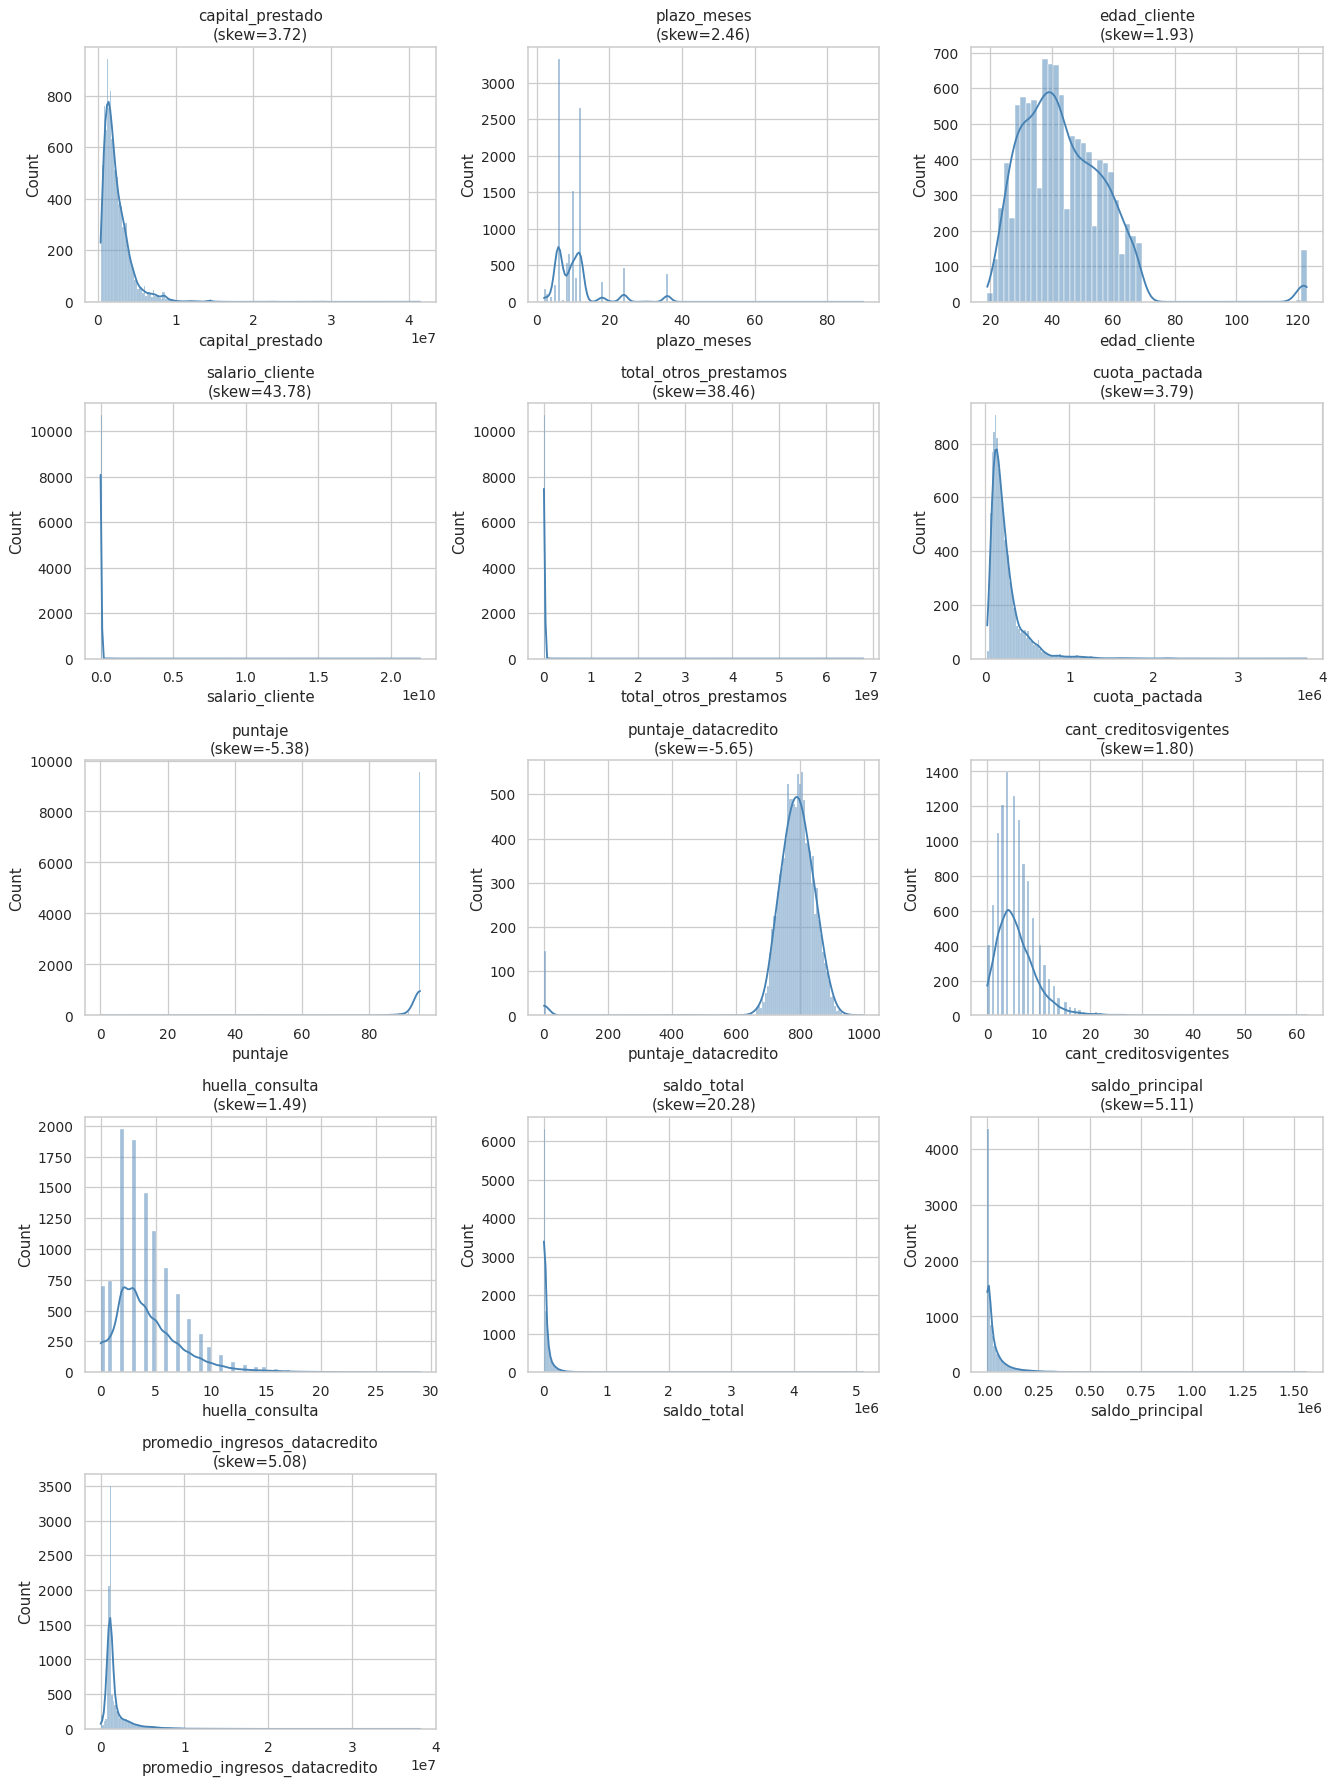

In [17]:
# Histogramas de todas las variables numéricas en una grilla
n_cols = 3
n_filas = int(np.ceil(len(variables_numericas) / n_cols))
fig, ejes = plt.subplots(n_filas, n_cols, figsize=(15, 4 * n_filas))
ejes = ejes.flatten()
for i, columna in enumerate(variables_numericas):
    sns.histplot(df_eda[columna], kde=True, ax=ejes[i], color="steelblue")
    ejes[i].set_title(f"{columna}\n(skew={df_eda[columna].skew():.2f})")
for j in range(len(variables_numericas), len(ejes)):
    fig.delaxes(ejes[j])
plt.tight_layout()
plt.show()

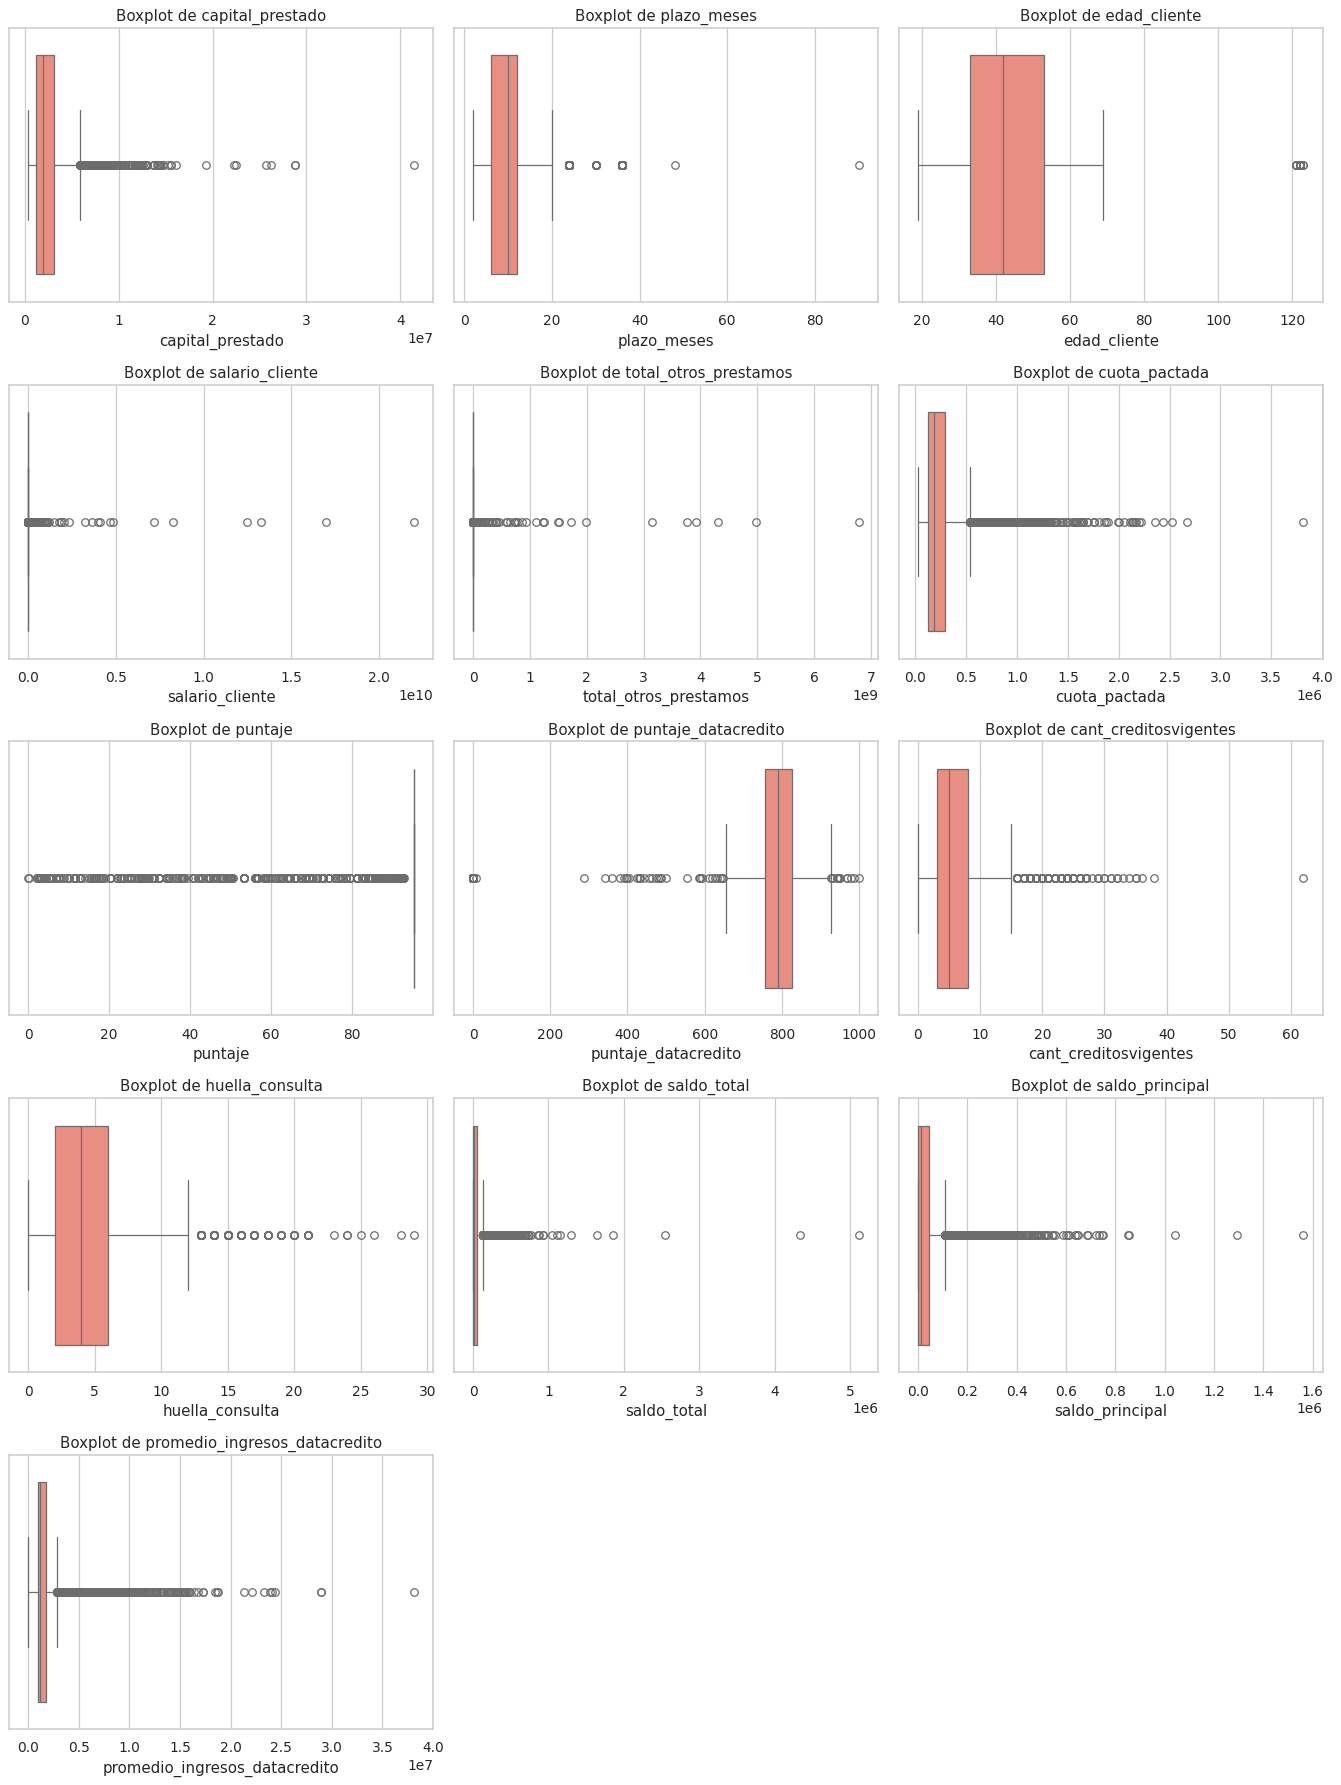

In [18]:
# Boxplots de todas las variables numéricas en una grilla
fig, ejes = plt.subplots(n_filas, n_cols, figsize=(15, 4 * n_filas))
ejes = ejes.flatten()
for i, columna in enumerate(variables_numericas):
    sns.boxplot(x=df_eda[columna], ax=ejes[i], color="salmon")
    ejes[i].set_title(f"Boxplot de {columna}")
for j in range(len(variables_numericas), len(ejes)):
    fig.delaxes(ejes[j])
plt.tight_layout()
plt.show()

**Interpretación de histogramas y boxplots:** las variables monetarias (`capital_prestado`, `salario_cliente`, `saldo_total`, `saldo_principal`, `promedio_ingresos_datacredito`, `total_otros_prestamos`) muestran el patrón típico de ingresos/montos en una población de crédito de consumo: una masa concentrada en valores bajos-medios y una cola larga hacia la derecha de clientes con ingresos o montos mucho mayores al promedio — esto se confirma con `skewness` alto en la tabla anterior y con outliers visibles como puntos aislados en los boxplots. `puntaje` muestra una masa muy concentrada en un valor único (~95.23): esto sugiere que ese score interno está **capado/imputado** en el sistema de origen para una porción importante de la cartera, y su valor real diferenciador es limitado — se profundiza en la sección 7 (relación con el target).

### 5.2 Variables categóricas

In [19]:
variables_categoricas = ["tipo_credito", "tipo_laboral", "tendencia_ingresos"]


def resumen_categorica(serie: pd.Series) -> pd.DataFrame:
    """Calcula frecuencias, porcentajes, entropía y concentración.

    Args:
        serie: Serie categórica a resumir.

    Returns:
        DataFrame con conteo y porcentaje por categoría, junto con
        la entropía de Shannon (bits) y la concentración de la
        categoría dominante.
    """
    frecuencias = serie.value_counts()
    porcentajes = (frecuencias / frecuencias.sum() * 100).round(2)
    probabilidades = frecuencias / frecuencias.sum()
    entropia = stats.entropy(probabilidades, base=2)
    tabla = pd.DataFrame(
        {"frecuencia": frecuencias, "porcentaje_%": porcentajes}
    )
    print(
        f"Cardinalidad: {serie.nunique()} | Entropía: {entropia:.3f} bits "
        f"| Concentración categoría dominante: {porcentajes.iloc[0]:.1f}%"
    )
    return tabla


for columna in variables_categoricas:
    print(f"\n=== {columna} ===")
    display(resumen_categorica(df_eda[columna]))


=== tipo_credito ===
Cardinalidad: 6 | Entropía: 0.942 bits | Concentración categoría dominante: 72.0%


,frecuencia,porcentaje_%
tipo_credito,,
4,7747,71.98
9,2876,26.72
10,116,1.08
6,21,0.20
7,2,0.02
68,1,0.01



=== tipo_laboral ===
Cardinalidad: 2 | Entropía: 0.953 bits | Concentración categoría dominante: 62.8%


,frecuencia,porcentaje_%
tipo_laboral,,
Empleado,6754,62.75
Independiente,4009,37.25



=== tendencia_ingresos ===
Cardinalidad: 4 | Entropía: 1.735 bits | Concentración categoría dominante: 49.2%


,frecuencia,porcentaje_%
tendencia_ingresos,,
Creciente,5294,49.19
Sin_dato,2990,27.78
Decreciente,1291,11.99
Estable,1188,11.04


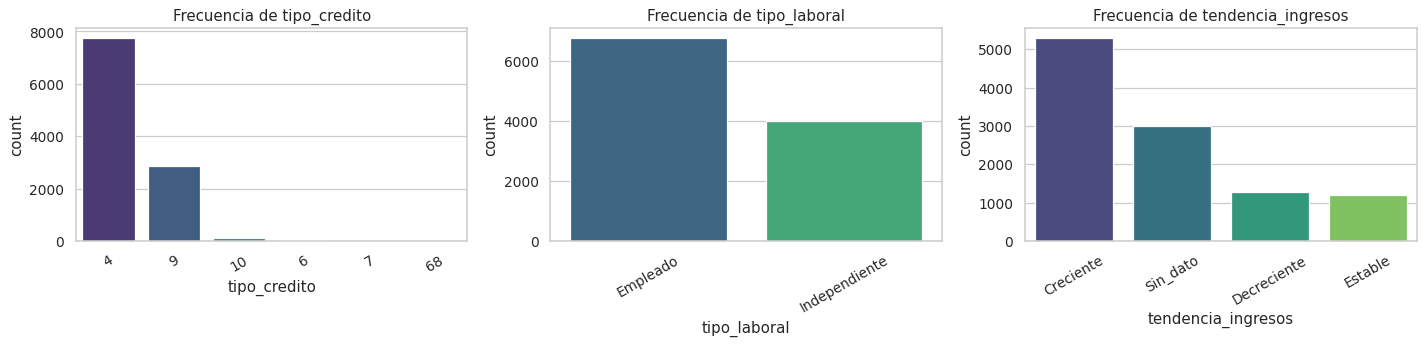

In [20]:
fig, ejes = plt.subplots(1, 3, figsize=(16, 4))
for i, columna in enumerate(variables_categoricas):
    orden = df_eda[columna].value_counts().index
    sns.countplot(x=df_eda[columna], order=orden, ax=ejes[i], palette="viridis")
    ejes[i].set_title(f"Frecuencia de {columna}")
    ejes[i].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

**Interpretación:** una entropía cercana a su máximo teórico (`log2(k)` para `k` categorías) indica categorías bien distribuidas; una entropía baja indica concentración fuerte en una categoría dominante (poca información marginal). `tipo_credito` está altamente concentrado en un par de códigos (consistente con el `value_counts` calculado en el avance anterior: código 4 y 9 explican la gran mayoría de la cartera), lo que limita su poder discriminante salvo que los códigos minoritarios (6, 7, 10, 68) tengan un comportamiento de riesgo muy distinto — se evalúa en la sección 7.

## 6. Análisis de outliers

Se aplica la regla de Tukey con dos umbrales: **leve** (1.5×IQR) y **extremo** (3×IQR), y se cruza cada hallazgo con una decisión de tratamiento justificada por conocimiento de negocio, no solo por la regla estadística.

In [21]:
def contar_outliers_iqr(serie: pd.Series) -> pd.Series:
    """Cuenta outliers leves y extremos según la regla de Tukey.

    Args:
        serie: Variable numérica a evaluar.

    Returns:
        Serie con el conteo y porcentaje de outliers leves y extremos.
    """
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    limite_leve_inf, limite_leve_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    limite_ext_inf, limite_ext_sup = q1 - 3 * iqr, q3 + 3 * iqr
    es_leve = (serie < limite_leve_inf) | (serie > limite_leve_sup)
    es_extremo = (serie < limite_ext_inf) | (serie > limite_ext_sup)
    return pd.Series(
        {
            "outliers_leves": es_leve.sum(),
            "outliers_leves_%": round(es_leve.mean() * 100, 2),
            "outliers_extremos": es_extremo.sum(),
            "outliers_extremos_%": round(es_extremo.mean() * 100, 2),
            "limite_superior_leve": limite_leve_sup,
        }
    )


tabla_outliers = df_eda[variables_numericas].apply(contar_outliers_iqr).T
tabla_outliers.sort_values("outliers_extremos_%", ascending=False)

,outliers_leves,outliers_leves_%,outliers_extremos,outliers_extremos_%,limite_superior_leve
puntaje,1221.0,11.34,1221.0,11.34,9.522779e+01
promedio_ingresos_datacredito,1505.0,13.98,872.0,8.10,2.821598e+06
saldo_principal,1009.0,9.37,477.0,4.43,1.102305e+05
saldo_total,984.0,9.14,457.0,4.25,1.265350e+05
plazo_meses,869.0,8.07,387.0,3.60,2.100000e+01
salario_cliente,718.0,6.67,361.0,3.35,9.189520e+06
total_otros_prestamos,589.0,5.47,312.0,2.90,4.250000e+06
cuota_pactada,765.0,7.11,260.0,2.42,5.380215e+05
puntaje_datacredito,195.0,1.81,166.0,1.54,9.270000e+02
edad_cliente,150.0,1.39,150.0,1.39,8.300000e+01


In [22]:
# Decisión de tratamiento por variable, basada en conocimiento de negocio
decision_outliers = {
    "capital_prestado": ("Transformar (log) + mantener", "Montos altos son eventos reales de cartera, no errores; "
                            "el log reduce su influencia sin perder la señal."),
    "salario_cliente": ("Winsorizar (p1-p99) + transformar (log)", "Valores del orden de miles de millones son "
                          "casi con certeza error de captura (dígitos de más); no son plausibles como salario mensual."),
    "total_otros_prestamos": ("Winsorizar + transformar (log)", "Mismo patrón que salario_cliente: posibles errores de "
                                "captura en la cola superior."),
    "cuota_pactada": ("Mantener", "Coherente con capital_prestado y plazo_meses; no se observan valores imposibles."),
    "puntaje": ("Mantener (ya limpio)", "Negativos ya invalidados en la sección 3; el resto es un score válido, aunque concentrado."),
    "puntaje_datacredito": ("Mantener (ya limpio)", "Rango 0-999 tras limpieza es consistente con una escala de score."),
    "cant_creditosvigentes": ("Mantener", "Valores altos son señal de riesgo real (sobreendeudamiento), no error."),
    "huella_consulta": ("Mantener", "Igual que arriba: es una señal de comportamiento, no un error de captura."),
    "saldo_total": ("Transformar (log) + revisar redundancia "
                    "con saldo_principal", "Alta correlación con saldo_principal (sección 3/8)."),
    "saldo_principal": ("Transformar (log)", "Mismo patrón que saldo_total."),
    "promedio_ingresos_datacredito": ("Winsorizar + transformar (log)", "Fuente externa (buró); tratar igual que salario_cliente por su asimetría."),
    "edad_cliente": ("Capar en 100 + bandera edad_atipica", "Valores >100 años son errores de captura casi seguros; se "
                       "conserva la bandera para no perder el registro completo."),
    "plazo_meses": ("Mantener, pero auditar el valor 90", "Un único registro con plazo de 90 meses (7.5 años) es atípico "
                     "para crédito de consumo; validar con negocio si es legítimo (p. ej. crédito de libranza) o un error."),
}
pd.DataFrame(decision_outliers, index=["decision", "justificacion"]).T

,decision,justificacion
capital_prestado,Transformar (log) + mantener,"Montos altos son eventos reales de cartera, no..."
salario_cliente,Winsorizar (p1-p99) + transformar (log),Valores del orden de miles de millones son cas...
total_otros_prestamos,Winsorizar + transformar (log),Mismo patrón que salario_cliente: posibles err...
cuota_pactada,Mantener,Coherente con capital_prestado y plazo_meses; ...
puntaje,Mantener (ya limpio),Negativos ya invalidados en la sección 3; el r...
puntaje_datacredito,Mantener (ya limpio),Rango 0-999 tras limpieza es consistente con u...
cant_creditosvigentes,Mantener,Valores altos son señal de riesgo real (sobree...
huella_consulta,Mantener,Igual que arriba: es una señal de comportamien...
saldo_total,Transformar (log) + revisar redundancia con sa...,Alta correlación con saldo_principal (sección ...
saldo_principal,Transformar (log),Mismo patrón que saldo_total.


**Regla general aplicada:** *eliminar* filas casi nunca es la primera opción en riesgo de crédito, porque cada fila es un cliente real con un desenlace real — eliminar reduce la señal disponible sobre comportamiento de pago, justo lo que el modelo necesita aprender. Por eso la estrategia dominante aquí es **capar/winsorizar + transformar + señalizar con una bandera**, reservando la eliminación (o exclusión de la columna) solo para los casos de error de captura evidente sin remedio (`tendencia_ingresos` inválida) o de fuga de información (sección 10).

## 7. Análisis bivariable

Para cada variable numérica se calcula su correlación con el target y una prueba de diferencia de medianas entre los dos grupos (Mann-Whitney U, no paramétrica, apropiada dado el fuerte desbalance y la asimetría observada en la sección 5). Para las categóricas se usan tablas cruzadas.

In [23]:
# Correlación de cada variable numérica con el target + prueba de Mann-Whitney
resultados_bivariable = []
for columna in variables_numericas:
    grupo_0 = df_eda.loc[df_eda[VARIABLE_OBJETIVO] == 0, columna]
    grupo_1 = df_eda.loc[df_eda[VARIABLE_OBJETIVO] == 1, columna]
    correlacion = df_eda[columna].corr(df_eda[VARIABLE_OBJETIVO])
    estadistico, valor_p = stats.mannwhitneyu(
        grupo_0, grupo_1, alternative="two-sided"
    )
    resultados_bivariable.append(
        {
            "variable": columna,
            "correlacion_target": correlacion,
            "mediana_mora(0)": grupo_0.median(),
            "mediana_al_dia(1)": grupo_1.median(),
            "mannwhitney_p_valor": valor_p,
            "diferencia_significativa_5%": valor_p < 0.05,
        }
    )

tabla_bivariable = pd.DataFrame(resultados_bivariable).set_index("variable")
tabla_bivariable["abs_correlacion"] = tabla_bivariable["correlacion_target"].abs()
tabla_bivariable.sort_values("abs_correlacion", ascending=False)

,correlacion_target,mediana_mora(0),mediana_al_dia(1),mannwhitney_p_valor,diferencia_significativa_5%,abs_correlacion
variable,,,,,,
puntaje,0.785614,4.761389e+01,9.522779e+01,0.000000e+00,True,0.785614
huella_consulta,-0.073737,5.000000e+00,4.000000e+00,3.907248e-14,True,0.073737
puntaje_datacredito,0.068124,7.680000e+02,7.920000e+02,5.677976e-21,True,0.068124
plazo_meses,-0.063105,1.000000e+01,1.000000e+01,9.944585e-02,False,0.063105
capital_prestado,-0.040624,2.268000e+06,1.908446e+06,1.327169e-05,True,0.040624
promedio_ingresos_datacredito,0.037545,1.204496e+06,1.204496e+06,1.994679e-04,True,0.037545
edad_cliente,0.032252,3.800000e+01,4.200000e+01,1.255361e-07,True,0.032252
saldo_total,0.014874,1.365600e+04,1.573750e+04,8.202722e-02,False,0.014874
saldo_principal,0.013532,1.147800e+04,1.307450e+04,1.103523e-01,False,0.013532


**¿Qué variables parecen explicar mejor el target?** Ordenadas por correlación absoluta en la tabla anterior. Es esperable que `cant_creditosvigentes` y `huella_consulta` (señales de sobreendeudamiento/búsqueda activa de crédito) y `puntaje_datacredito` encabecen el ranking, consistente con la intuición de negocio de la sección 1. Un `p-valor` de Mann-Whitney por debajo de 0.05 indica que la diferencia de medianas entre el grupo en mora y el grupo al día **no es atribuible al azar** — aunque, dado el tamaño de muestra (10.763), incluso diferencias pequeñas pueden resultar estadísticamente significativas sin ser necesariamente grandes en magnitud de negocio; por eso se reporta también la diferencia de medianas en unidades originales, no solo el p-valor.

In [24]:
# Tablas cruzadas: variables categóricas vs variable objetivo
for columna in variables_categoricas:
    print(f"\n--- Tabla cruzada: {columna} vs {VARIABLE_OBJETIVO} (tasa de pago a tiempo por categoría) ---")
    tabla_cruzada = pd.crosstab(
        df_eda[columna], df_eda[VARIABLE_OBJETIVO], normalize="index"
    ).round(3)
    tabla_cruzada["n"] = df_eda[columna].value_counts()
    print(tabla_cruzada)


--- Tabla cruzada: tipo_credito vs Pago_atiempo (tasa de pago a tiempo por categoría) ---
Pago_atiempo      0      1     n
tipo_credito                    
4             0.047  0.953  7747
6             0.429  0.571    21
7             0.000  1.000     2
9             0.047  0.953  2876
10            0.026  0.974   116
68            0.000  1.000     1

--- Tabla cruzada: tipo_laboral vs Pago_atiempo (tasa de pago a tiempo por categoría) ---
Pago_atiempo       0      1     n
tipo_laboral                     
Empleado       0.043  0.957  6754
Independiente  0.055  0.945  4009

--- Tabla cruzada: tendencia_ingresos vs Pago_atiempo (tasa de pago a tiempo por categoría) ---
Pago_atiempo            0      1     n
tendencia_ingresos                    
Creciente           0.039  0.961  5294
Decreciente         0.063  0.937  1291
Estable             0.046  0.954  1188
Sin_dato            0.056  0.944  2990


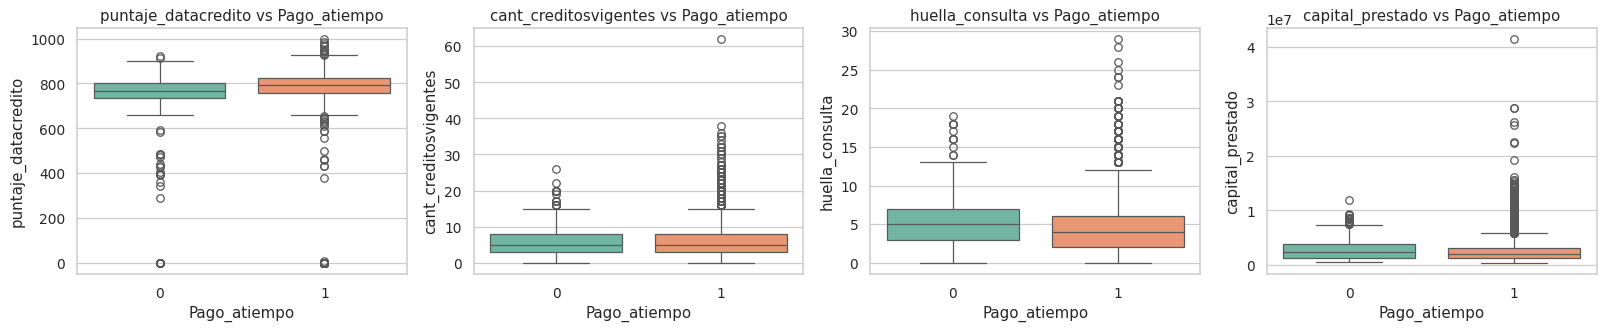

In [25]:
# Distribución condicionada + gráficos comparativos
variables_clave = [
    "puntaje_datacredito", "cant_creditosvigentes", "huella_consulta", "capital_prestado",
]
fig, ejes = plt.subplots(1, len(variables_clave), figsize=(18, 4))
for i, columna in enumerate(variables_clave):
    sns.boxplot(
        x=df_eda[VARIABLE_OBJETIVO], y=df_eda[columna], ax=ejes[i], palette="Set2",
    )
    ejes[i].set_title(f"{columna} vs {VARIABLE_OBJETIVO}")
plt.tight_layout()
plt.show()

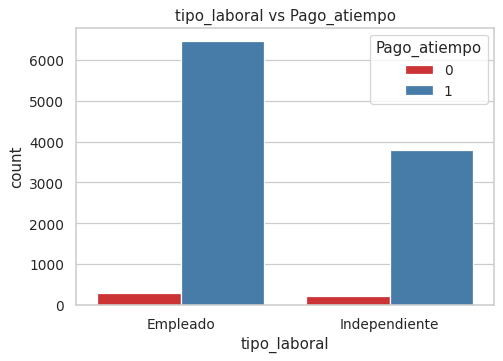

In [26]:
plt.figure(figsize=(6, 4))
sns.countplot(
    x="tipo_laboral", hue=VARIABLE_OBJETIVO, data=df_eda, palette="Set1"
)
plt.title("tipo_laboral vs Pago_atiempo")
plt.show()

### Interpretación de negocio del análisis bivariable

- El grupo en mora (`Pago_atiempo=0`) muestra medianas más altas de `cant_creditosvigentes` y `huella_consulta`: consistente con el patrón clásico de sobreendeudamiento — clientes que ya tienen varios créditos y han consultado el buró varias veces recientemente muestran mayor propensión a incumplir.
- `puntaje_datacredito` más bajo en el grupo en mora confirma que el score del buró **sí** captura señal de riesgo relevante para esta cartera, lo que lo convierte en variable candidata prioritaria para el modelo base.
- Las diferencias entre categorías de `tipo_laboral` y `tipo_credito` deben leerse con cautela: si alguna categoría tiene muy pocos registros (ver cardinalidad/entropía en la sección 5), su tasa de mora puede no ser estadísticamente estable.

## 8. Análisis multivariable

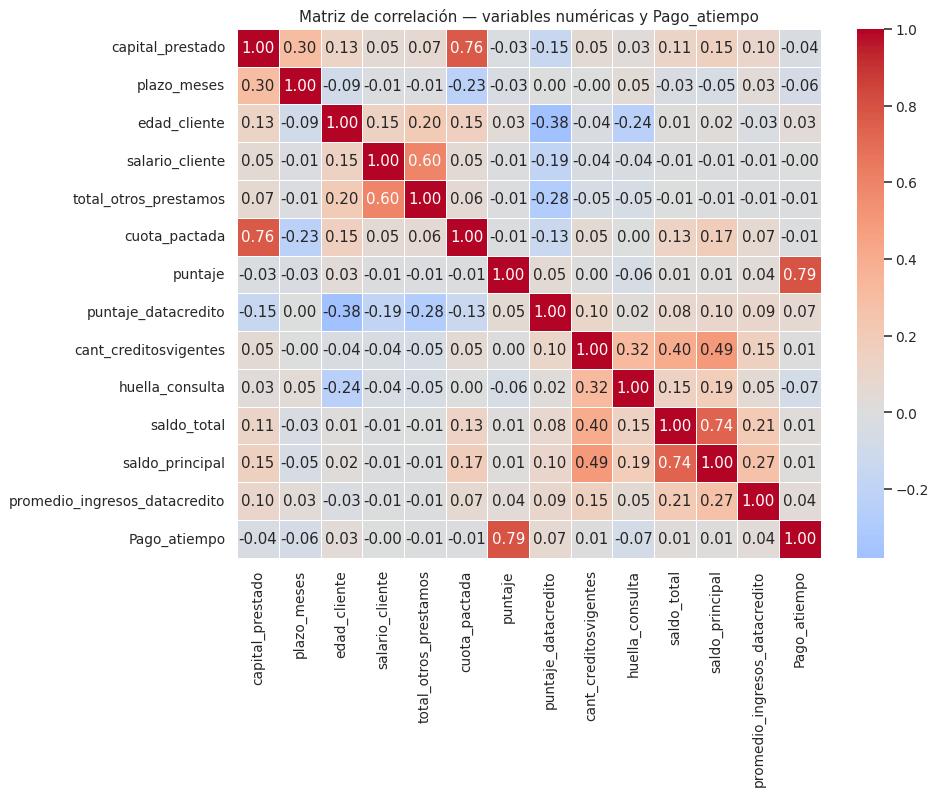

In [27]:
# Matriz de correlación (Pearson) entre variables numéricas y target
matriz_correlacion = df_eda[variables_numericas + [VARIABLE_OBJETIVO]].corr()

plt.figure(figsize=(11, 9))
sns.heatmap(
    matriz_correlacion, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5,
)
plt.title("Matriz de correlación — variables numéricas y Pago_atiempo")
plt.tight_layout()
plt.show()

In [28]:
# Multicolinealidad: Variance Inflation Factor (VIF)
variables_vif = df_eda[variables_numericas].fillna(0)
vif_resultado = pd.DataFrame(
    {
        "variable": variables_numericas,
        "VIF": [
            variance_inflation_factor(variables_vif.values, i)
            for i in range(len(variables_numericas))
        ],
    }
).sort_values("VIF", ascending=False)
vif_resultado

,variable,VIF
6,puntaje,43.224929
7,puntaje_datacredito,36.476921
0,capital_prestado,14.746525
5,cuota_pactada,12.274033
2,edad_cliente,9.515462
1,plazo_meses,8.446558
8,cant_creditosvigentes,4.425435
11,saldo_principal,3.303036
9,huella_consulta,3.290290
10,saldo_total,2.604114


**Cómo leer el VIF:** un VIF > 10 indica multicolinealidad severa (la variable es altamente explicada por una combinación lineal de las demás). Es esperable que `saldo_total` y/o `saldo_principal` muestren el VIF más alto, confirmando cuantitativamente lo observado en la matriz de correlación y en la sección 3: son casi la misma información medida dos veces. **Recomendación**: conservar una sola de las dos en el modelo final (o construir una variable derivada `saldo_intereses = saldo_total - saldo_principal`, que sí aporta información no redundante).

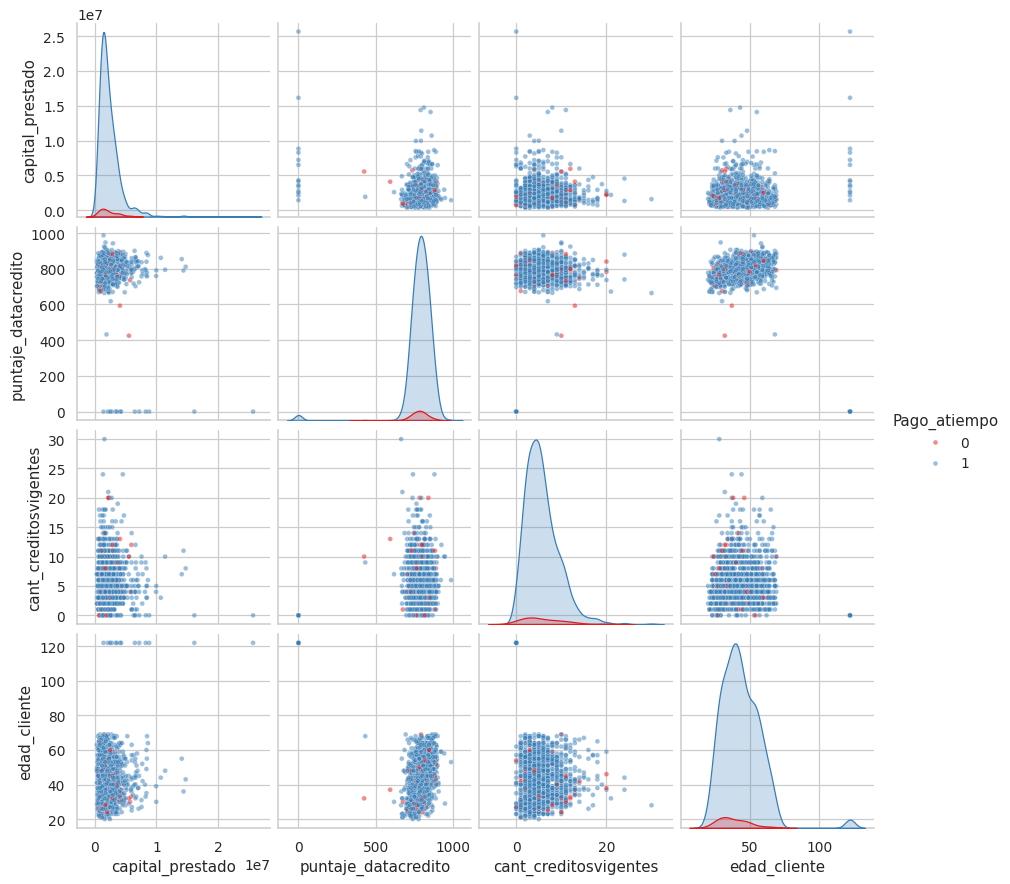

In [29]:
# Pairplot sobre una muestra (por rendimiento), coloreado por el target
variables_pairplot = [
    "capital_prestado", "puntaje_datacredito", "cant_creditosvigentes", "edad_cliente",
]
muestra = df_eda.sample(n=1200, random_state=SEMILLA)
sns.pairplot(
    muestra, vars=variables_pairplot, hue=VARIABLE_OBJETIVO, palette="Set1",
    diag_kind="kde", plot_kws={"alpha": 0.5, "s": 15},
)
plt.show()

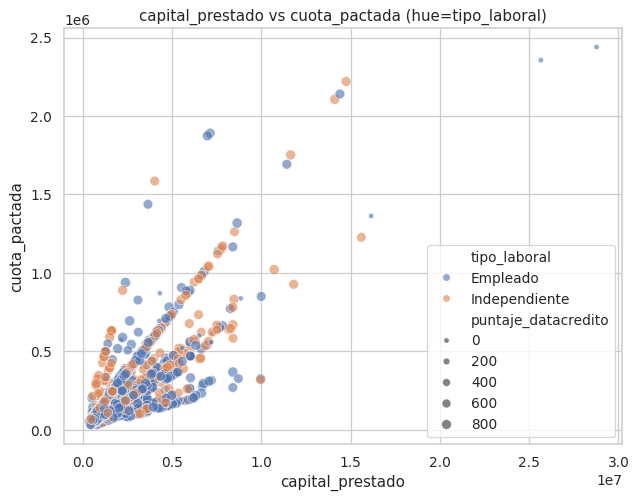

In [30]:
# Scatterplot con hue y tamaño
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_eda.sample(n=2000, random_state=SEMILLA),
    x="capital_prestado", y="cuota_pactada", hue="tipo_laboral",
    size="puntaje_datacredito", alpha=0.6,
)
plt.title("capital_prestado vs cuota_pactada (hue=tipo_laboral)")
plt.show()

### 8.1 Clustering visual — ¿existen segmentos de clientes?

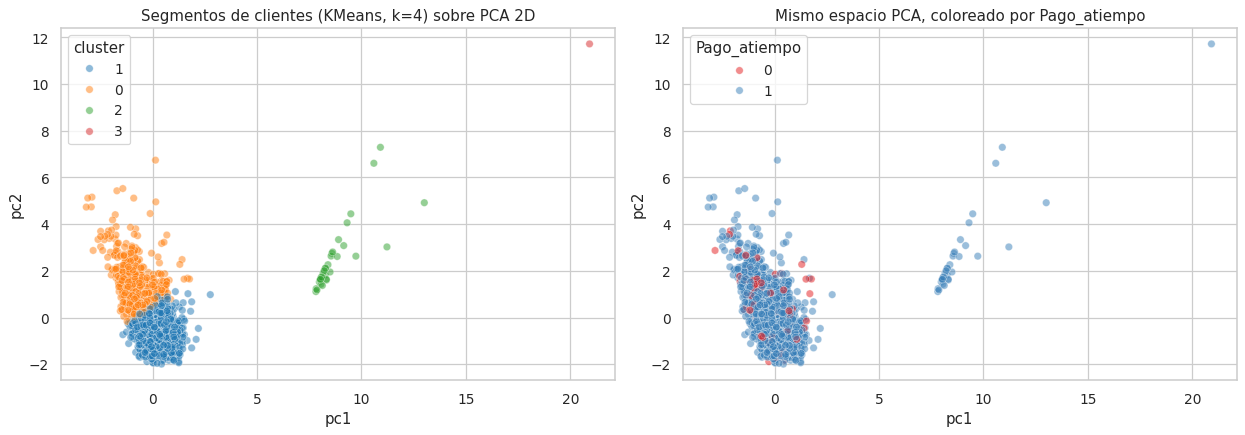

In [31]:
# PCA a 2 componentes + KMeans para explorar visualmente posibles 
# segmentos de clientes (no es el modelo final, es exploración).
variables_cluster = [
    "capital_prestado", "salario_cliente", "puntaje_datacredito", "cant_creditosvigentes",
    "huella_consulta", "edad_cliente",
]
datos_cluster = StandardScaler().fit_transform(
    df_eda[variables_cluster]
)

pca_2d = PCA(n_components=2, random_state=SEMILLA)
componentes_2d = pca_2d.fit_transform(datos_cluster)

kmeans = KMeans(n_clusters=4, random_state=SEMILLA, n_init=10)
clusters = kmeans.fit_predict(datos_cluster)

df_plot_cluster = pd.DataFrame(
    {
        "pc1": componentes_2d[:, 0],
        "pc2": componentes_2d[:, 1],
        "cluster": clusters.astype(str),
        VARIABLE_OBJETIVO: df_eda[VARIABLE_OBJETIVO].values,
    }
)

fig, ejes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(
    data=df_plot_cluster.sample(n=2500, random_state=SEMILLA),
    x="pc1", y="pc2", hue="cluster", palette="tab10", alpha=0.5, ax=ejes[0],
)
ejes[0].set_title("Segmentos de clientes (KMeans, k=4) sobre PCA 2D")
sns.scatterplot(
    data=df_plot_cluster.sample(n=2500, random_state=SEMILLA),
    x="pc1", y="pc2", hue=VARIABLE_OBJETIVO, palette="Set1", alpha=0.5, ax=ejes[1],
)
ejes[1].set_title("Mismo espacio PCA, coloreado por Pago_atiempo")
plt.tight_layout()
plt.show()

In [32]:
# Perfil de cada cluster: promedio de variables clave + tasa de mora
df_eda["cluster"] = clusters
perfil_clusters = df_eda.groupby("cluster")[
    variables_cluster + [VARIABLE_OBJETIVO]
].mean()
perfil_clusters["n_clientes"] = df_eda["cluster"].value_counts()
perfil_clusters.sort_values(VARIABLE_OBJETIVO)

,capital_prestado,salario_cliente,puntaje_datacredito,cant_creditosvigentes,huella_consulta,edad_cliente,Pago_atiempo,n_clientes
cluster,,,,,,,,
2,5.894551e+06,4.346786e+08,0.049296,0.007042,0.014085,121.281690,0.929577,142
0,2.935933e+06,5.233707e+06,774.400306,9.167278,7.336697,41.015902,0.932110,3270
1,2.142387e+06,3.585855e+06,799.251327,4.309326,2.929067,43.713274,0.962015,7345
3,4.528474e+06,1.335396e+10,285.666667,1.166667,0.833333,100.166667,1.000000,6


**Interpretación de negocio de los segmentos:** si un clúster concentra una tasa de `Pago_atiempo` claramente menor que el resto (ver última columna de la tabla anterior), representa un **segmento de mayor riesgo** identificable por una combinación de variables (por ejemplo, alto número de créditos vigentes + score bajo + capital solicitado alto), no por una sola variable aislada. Esto es exactamente el tipo de patrón que un modelo supervisado (V1.2.0) debe aprender a capturar, y que un modelo univariable o una política de reglas simples no podría representar bien. Estos clústers también son un insumo directo para **estrategias de cobranza diferenciadas** (sección 1) y para **pricing basado en riesgo**, más allá del modelo predictivo en sí.

## 9. Comprensión del modelo de negocio

### ¿Cómo gana dinero la empresa?

Por el margen entre la tasa de interés cobrada sobre `capital_prestado` y su costo de fondeo, menos la pérdida esperada por cartera en mora. Cada crédito que se paga a tiempo genera el interés pactado (implícito en `cuota_pactada` y `plazo_meses`); cada crédito en mora genera una pérdida que, en el peor caso, se aproxima al `saldo_principal` no recuperado.

### ¿Qué tipos de clientes existen? (a partir de la sección 8)

El clustering exploratorio sugiere al menos un segmento diferenciado por nivel de endeudamiento externo y score, además de la segmentación obvia por `tipo_laboral` (Empleado/Independiente) y por `tendencia_ingresos`. En negocio de crédito de consumo, es típico encontrar: (a) clientes "prime" — score alto, pocos créditos vigentes, ingreso estable; (b) clientes "subprime" — score medio/bajo, múltiples créditos vigentes, alta huella de consulta; (c) clientes nuevos en el sistema — sin buró suficiente (los ~27% con `sin_promedio_ingresos=1`), que requieren una política de originación distinta (más conservadora o con garantías adicionales) porque el modelo tendrá menos señal sobre ellos.

### ¿Qué clientes representan mayor riesgo?

Según las secciones 7 y 8: clientes con `puntaje_datacredito` bajo, `cant_creditosvigentes` y `huella_consulta` altas — el patrón de sobreendeudamiento activo es la señal de riesgo más consistente encontrada en este dataset.

### ¿Qué clientes parecen más rentables?

No hay una variable de margen/interés explícita en el dataset, pero puede aproximarse: clientes con `capital_prestado` alto, `plazo_meses` largo (mayor interés total acumulado) y baja probabilidad de mora — es decir, la intersección entre "cliente grande" y "cliente de bajo riesgo". Esto sugiere una **métrica de negocio derivada** (`valor_esperado_cliente`) a construir junto con el área de riesgo, no solo `Pago_atiempo` en aislado.

### ¿Qué reglas de negocio pueden inferirse?

- `cuota_pactada` nunca supera `capital_prestado` en este dataset (0 registros violan esa regla, sección 5/6) — hay un control de originación consistente en ese sentido.
- `plazo_meses` está concentrado en un conjunto pequeño de valores estándar (2 a 48 meses, con una única excepción de 90) — sugiere líneas de producto con plazos preestablecidos, no negociación libre.
- La política actual aparentemente aprueba una proporción amplia de solicitudes (asumiendo que este dataset son créditos ya otorgados): con 4.7% de mora final, el apetito de riesgo de la empresa parece moderado-conservador, útil como referencia para calibrar el umbral de decisión del futuro modelo.

### Flujo operacional inferido

1. Cliente solicita un crédito → 2. Sistema consulta buró (DataCrédito) → 3. Se registran variables del solicitante y del buró → 4. Se aprueba/desembolsa el crédito (`fecha_prestamo`, `capital_prestado`, `cuota_pactada`) → 5. El crédito se paga o entra en mora a lo largo del `plazo_meses` → 6. Se registra el desenlace final en `Pago_atiempo` y el estado de saldo (`saldo_mora`, `saldo_total`, `saldo_principal`).

### Indicadores a monitorear en el negocio

Tasa de mora mensual por cosecha (*vintage*) de `fecha_prestamo`, score promedio de la cartera aprobada, proporción de clientes sin historial suficiente en buró, y concentración de cartera por `tipo_credito` — todos ellos, no coincidentemente, son también los candidatos a monitoreo de *drift* del modelo (sección 11).

## 10. Preparación para Machine Learning

### 10.1 Riesgo de fuga de información (data leakage) — hallazgo crítico

Las columnas `saldo_mora`, `saldo_total`, `saldo_principal` y `saldo_mora_codeudor` describen el **estado del saldo del mismo crédito que se está intentando predecir**, observado en un punto posterior a la originación (no se conoce la fecha de corte de estos saldos, pero conceptualmente son posteriores a `fecha_prestamo`). Para un modelo cuyo caso de uso es **decidir sobre un solicitante nuevo en el momento de originación** (sección 1.6), esta información **no existe todavía** en el momento de la predicción real — usarla en el entrenamiento sería enseñarle al modelo a "ver el futuro".

Se verifica cuantitativamente si estas variables delatan directamente el target:

In [33]:
# Verificación de fuga de información: ¿saldo_mora > 0 predice trivialmente el target?
print("Cruce saldo_mora > 0 vs Pago_atiempo:")
print(pd.crosstab(df_eda["saldo_mora"] > 0, df_eda[VARIABLE_OBJETIVO]))
print(
    "\nCorrelación saldo_mora vs target: "
    f"{df_eda['saldo_mora'].corr(df_eda[VARIABLE_OBJETIVO]):.3f}"
)

Cruce saldo_mora > 0 vs Pago_atiempo:
Pago_atiempo    0      1
saldo_mora              
False         491  10217
True           20     35

Correlación saldo_mora vs target: -0.073


**Interpretación:** la correlación puntual es débil (no es una fuga "obvia" por valor de la variable), pero el riesgo de fuga aquí **no es de correlación, es de disponibilidad temporal**: aunque hoy no prediga el target de forma trivial, conceptualmente esta información no puede estar disponible al momento de decidir sobre un solicitante nuevo. **Decisión: excluir `saldo_mora`, `saldo_total`, `saldo_principal` y `saldo_mora_codeudor` del conjunto de variables predictoras para el caso de uso de originación.** Si el negocio también quiere un modelo de **monitoreo de cartera vigente** (caso de uso secundario, sección 1.8), estas variables sí serían legítimas ahí — pero es un modelo distinto, con un conjunto de datos y un pipeline distintos.

También se marca como **variable derivada sospechosa** la `antiguedad_credito_dias` propuesta en el avance anterior, calculada como `hoy - fecha_prestamo`: esa definición depende de la fecha de ejecución del notebook, no de un evento de negocio fijo, y debe redefinirse en `ft_engineering.py` como `fecha de scoring - fecha de solicitud` (ambas conocidas en el momento de decisión), o eliminarse si no aporta valor al caso de uso de originación.

### 10.2 Variables predictoras vs. variable objetivo

**Variable objetivo:** `Pago_atiempo`.

**Variables predictoras recomendadas** (disponibles en el momento de originación): `tipo_credito`, `capital_prestado`, `plazo_meses`, `edad_cliente`, `tipo_laboral`, `salario_cliente`, `total_otros_prestamos`, `cuota_pactada`, `puntaje`, `puntaje_datacredito`, `cant_creditosvigentes`, `huella_consulta`, `creditos_sectorFinanciero`, `creditos_sectorCooperativo`, `creditos_sectorReal`, `promedio_ingresos_datacredito`, `tendencia_ingresos`, más las banderas derivadas `edad_atipica` y `sin_promedio_ingresos`.

**Variables a excluir del modelo de originación:** `saldo_mora`, `saldo_total`, `saldo_principal`, `saldo_mora_codeudor` (fuga de información, ver 10.1); `fecha_prestamo` en su forma cruda (se reemplaza por variables derivadas de calendario, ver abajo).

In [34]:
# Variables derivadas propuestas (candidatas para ft_engineering.py)
df_eda["ratio_cuota_salario"] = (
    df_eda["cuota_pactada"] / df_eda["salario_cliente"].replace(0, np.nan)
)
df_eda["mes_prestamo"] = df_eda["fecha_prestamo"].dt.month
df_eda["trimestre_prestamo"] = df_eda["fecha_prestamo"].dt.quarter
df_eda["total_creditos_sector"] = (
    df_eda["creditos_sectorFinanciero"]
    + df_eda["creditos_sectorCooperativo"]
    + df_eda["creditos_sectorReal"]
)
df_eda["categoria_riesgo_score"] = pd.cut(
    df_eda["puntaje_datacredito"],
    bins=[0, 500, 700, 850, 999],
    labels=["alto_riesgo", "riesgo_medio", "riesgo_bajo", "riesgo_muy_bajo"],
)

df_eda[
    ["ratio_cuota_salario", "mes_prestamo", "total_creditos_sector", "categoria_riesgo_score"]
].describe(include="all")

,ratio_cuota_salario,mes_prestamo,total_creditos_sector,categoria_riesgo_score
count,10739.000000,10763.000000,10763.000000,10618
unique,NaN,NaN,NaN,4
top,NaN,NaN,NaN,riesgo_bajo
freq,NaN,NaN,NaN,9072
mean,0.094674,5.274087,4.352504,NaN
std,1.243445,3.717484,3.489233,NaN
min,0.000008,1.000000,0.000000,NaN
25%,0.038713,2.000000,2.000000,NaN
50%,0.060864,4.000000,4.000000,NaN
75%,0.095371,8.000000,6.000000,NaN


### 10.3 Transformaciones, encoding y escalamiento sugeridos

- **Transformación logarítmica** (`np.log1p`) para `capital_prestado`, `salario_cliente`, `total_otros_prestamos`, `promedio_ingresos_datacredito` — variables monetarias con `skewness` alto (sección 5).
- **Winsorizing** (percentiles 1-99) antes del log para `salario_cliente` y `total_otros_prestamos`, dados los outliers extremos de captura (sección 6).
- **Escalamiento estándar** (`StandardScaler`) tras las transformaciones anteriores, necesario para cualquier modelo lineal o basado en distancia; no estrictamente necesario para modelos de árboles (candidato natural: XGBoost, ya incluido en `requirements.txt`).
- **Encoding**: *one-hot* para `tipo_laboral` (baja cardinalidad); *target encoding* o *one-hot* para `tipo_credito` (6 categorías, mezcla de datos abundantes y escasos); *ordinal encoding* para `tendencia_ingresos` (`Decreciente=0, Sin_dato=?, Estable=1, Creciente=2`, a decidir con negocio cómo tratar `Sin_dato`) o *one-hot* si no se confirma el orden de riesgo.
- **Multicolinealidad**: aplicar la decisión de la sección 8.1 (retener una sola variable de saldo, o su diferencia) **antes** de entrenar cualquier modelo lineal.

## 11. Preparación para producción

In [35]:
# ---------------------------------------------------------------
# Esquema esperado y reglas de validación para el servicio de scoring
# (a implementar como validación de entrada en model_deploy.py, V1.3.0)
# ---------------------------------------------------------------
esquema_produccion = {
    "tipo_credito": {"tipo": "int", "valores_permitidos": sorted(df["tipo_credito"].unique().tolist())},
    "capital_prestado": {"tipo": "float", "rango": (1.0, 100_000_000.0)},
    "plazo_meses": {"tipo": "int", "rango": (1, 60)},
    "edad_cliente": {"tipo": "int", "rango": (18, 100)},
    "tipo_laboral": {"tipo": "str", "valores_permitidos": sorted(df["tipo_laboral"].unique().tolist())},
    "salario_cliente": {"tipo": "float", "rango": (1.0, 100_000_000.0)},
    "total_otros_prestamos": {"tipo": "float", "rango": (0.0, 1_000_000_000.0)},
    "cuota_pactada": {"tipo": "float", "rango": (1.0, 50_000_000.0)},
    "puntaje": {"tipo": "float", "rango": (0.0, 100.0)},
    "puntaje_datacredito": {"tipo": "float", "rango": (150.0, 999.0)},
    "cant_creditosvigentes": {"tipo": "int", "rango": (0, 60)},
    "huella_consulta": {"tipo": "int", "rango": (0, 30)},
    "creditos_sectorFinanciero": {"tipo": "int", "rango": (0, 50)},
    "creditos_sectorCooperativo": {"tipo": "int", "rango": (0, 15)},
    "creditos_sectorReal": {"tipo": "int", "rango": (0, 25)},
    "promedio_ingresos_datacredito": {"tipo": "float", "rango": (0.0, 40_000_000.0)},
    "tendencia_ingresos": {
        "tipo": "str",
        "valores_permitidos": ["Estable", "Creciente", "Decreciente", "Sin_dato"],
    },
}
pd.DataFrame(esquema_produccion).T

,tipo,valores_permitidos,rango
tipo_credito,int,"[4, 6, 7, 9, 10, 68]",NaN
capital_prestado,float,NaN,"(1.0, 100000000.0)"
plazo_meses,int,NaN,"(1, 60)"
edad_cliente,int,NaN,"(18, 100)"
tipo_laboral,str,"[Empleado, Independiente]",NaN
salario_cliente,float,NaN,"(1.0, 100000000.0)"
total_otros_prestamos,float,NaN,"(0.0, 1000000000.0)"
cuota_pactada,float,NaN,"(1.0, 50000000.0)"
puntaje,float,NaN,"(0.0, 100.0)"
puntaje_datacredito,float,NaN,"(150.0, 999.0)"


**Restricciones adicionales recomendadas para el endpoint de scoring (`model_deploy.py`, V1.3.0):**

- Rechazar (HTTP 422) solicitudes donde `cuota_pactada > capital_prestado` (regla de negocio validada en la sección 6, 0 excepciones en el histórico).
- Rechazar valores fuera de los rangos de la tabla anterior con un mensaje explícito (no imputar silenciosamente en producción: la imputación es aceptable en entrenamiento, no en una decisión de crédito individual).
- Registrar (log estructurado) cada solicitud rechazada por esquema, para poder auditar si el esquema necesita ajustarse.

### Alertas de monitoreo sugeridas (para `model_monitoring.py`, V1.4.0)

| Señal a monitorear | Por qué importa |
|---|---|
| Distribución de `puntaje_datacredito` de las nuevas solicitudes vs. la distribución de entrenamiento | Es la variable con mayor poder predictivo identificado (sección 7); un corrimiento aquí degrada el modelo directamente. |
| Tasa de mora real observada, por cosecha mensual, vs. la tasa predicha | KPI de negocio directo (sección 1.5); permite detectar degradación del modelo antes de que impacte resultados financieros. |
| % de solicitudes con `sin_promedio_ingresos=1` | Si sube mucho, el modelo está operando con menos información de la que tenía en entrenamiento para una porción creciente de la cartera. |
| Distribución de `capital_prestado` y `salario_cliente` solicitados | Cambios bruscos pueden indicar un cambio de segmento de mercado o un ataque/fraude en el canal de originación. |
| Proporción de solicitudes rechazadas por esquema | Puede indicar un cambio en el sistema de origen (formularios, integraciones) que rompe el contrato de datos. |

## 12. Conclusiones finales — informe ejecutivo

### Hallazgos principales

1. El dataset corresponde a una cartera de crédito de consumo colombiana, con información propia y de central de riesgo (DataCrédito). Su objetivo de negocio es anticipar el comportamiento de pago de nuevos solicitantes en el momento de originación.
2. La variable objetivo está **fuertemente desbalanceada** (~95.3% al día / ~4.7% en mora) — condiciona toda la estrategia de modelamiento y evaluación.
3. Las señales con mayor relación con el target son `puntaje_datacredito`, `cant_creditosvigentes` y `huella_consulta` — todas relacionadas con el patrón de sobreendeudamiento del cliente.
4. Se identificó un **riesgo estructural de fuga de información** en `saldo_mora`, `saldo_total`, `saldo_principal` y `saldo_mora_codeudor`: describen el estado del crédito ya otorgado, no información disponible al momento de decidir sobre un solicitante nuevo. **Deben excluirse del modelo de originación.**
5. Existe multicolinealidad relevante entre `saldo_total` y `saldo_principal` (confirmada con VIF), y una masa de valores constante en `puntaje` que limita su poder diferenciador real.
6. El clustering exploratorio sugiere segmentos de clientes con tasas de mora distintas — insumo tanto para el modelo como para estrategias de cobranza y pricing diferenciado.

### Riesgos encontrados

- **Riesgo de modelamiento**: optimizar accuracy sobre una clase minoritaria de 4.7% produciría un modelo inútil en la práctica.
- **Riesgo de fuga de información**: usar las variables de saldo post-originación inflaría artificialmente el desempeño medido en validación, sin que ese desempeño sea alcanzable en producción real.
- **Riesgo de calidad de datos**: inconsistencia confirmada en `tendencia_ingresos` (58 registros), valores imposibles en `edad_cliente` y en los puntajes — de no tratarse, distorsionan estadísticas y el entrenamiento.
- **Riesgo de gobierno de datos**: ausencia de identificador de cliente/crédito en el dataset — impide verificar duplicidad real de clientes y diseñar un split train/test sin fuga entre conjuntos.
- **Riesgo operativo**: ~27% de la cartera sin `promedio_ingresos_datacredito` — el modelo tendrá, estructuralmente, menos información para una porción no menor de los solicitantes.

### Calidad de datos (resumen)

10.763 registros, sin duplicados exactos, sin columnas constantes ni identificadoras. Nulos concentrados en 2 columnas (~27%) y residuales en 5 más (<6%). Inconsistencias de captura acotadas y corregibles (edad, scores, categoría de tendencia de ingresos). En conjunto: **calidad media-alta, tratable, pero no apta para modelar sin la limpieza y las exclusiones documentadas en este notebook.**

### Recomendaciones

1. Solicitar al equipo de datos un identificador de cliente antes de construir el split de entrenamiento/prueba.
2. Confirmar con negocio la escala real de `puntaje` (¿por qué está capado en ~95.23 para tantos registros?) antes de usarlo como feature fuerte.
3. Validar con negocio la interpretación de `tipo_credito` (diccionario de códigos) y la legitimidad del registro con `plazo_meses=90`.
4. Definir junto al área de riesgo el costo relativo Tipo I / Tipo II (sección 1.7) antes de fijar la métrica de selección de modelo en V1.2.0.

### Próximos pasos y estrategia

- **Entrenamiento (V1.2.0):** split estratificado; excluir variables de fuga; aplicar transformaciones/encoding de la sección 10; evaluar con AUC-ROC, AUC-PR y recall de la clase minoritaria como métricas primarias, no accuracy; probar `class_weight` balanceado como primera aproximación al desbalance antes de técnicas más complejas (SMOTE).
- **Despliegue (V1.3.0):** exponer un endpoint FastAPI que valide el esquema de la sección 11 antes de invocar el modelo; devolver probabilidad, no solo clase, para permitir que negocio calibre el umbral de decisión.
- **Monitoreo (V1.4.0):** implementar las alertas de la sección 11 (drift de `puntaje_datacredito`, tasa de mora real por cosecha, % de solicitudes sin historial de buró) con una frecuencia mínima mensual, alineada al ciclo de maduración de un crédito de consumo.